In [1]:
# Bloco 1: Análise Exploratória Inicial
# Cole isso na primeira célula do seu notebook e execute.

import pandas as pd

# Se os arquivos não estiverem na mesma pasta do seu notebook,
# ajuste o caminho. Ex: 'C:/Users/SeuUsuario/Documentos/train.csv'
try:
    df_train = pd.read_csv('train.csv')
    df_test = pd.read_csv('test.csv')

    print("===========================================")
    print("### INFORMAÇÕES DO DATASET DE TREINO ###")
    print("===========================================\n")

    print("--- 1. Primeiras 5 linhas (df_train.head()) ---\n")
    print(df_train.head())
    print("\n-------------------------------------------\n")

    print("--- 2. Informações Gerais (df_train.info()) ---\n")
    df_train.info()
    print("\n-------------------------------------------\n")

    print("--- 3. Contagem de Valores Ausentes (df_train.isnull().sum()) ---\n")
    print(df_train.isnull().sum())
    print("\n-------------------------------------------\n")


    print("\n===========================================")
    print("### INFORMAÇÕES DO DATASET DE TESTE ###")
    print("===========================================\n")

    print("--- 1. Primeiras 5 linhas (df_test.head()) ---\n")
    print(df_test.head())
    print("\n-------------------------------------------\n")

    print("--- 2. Contagem de Valores Ausentes (df_test.isnull().sum()) ---\n")
    print(df_test.isnull().sum())
    print("\n-------------------------------------------\n")


except FileNotFoundError:
    print("ERRO: Arquivo 'train.csv' ou 'test.csv' não encontrado.")
    print("Por favor, verifique se os arquivos estão na pasta correta ou ajuste o caminho.")

### INFORMAÇÕES DO DATASET DE TREINO ###

--- 1. Primeiras 5 linhas (df_train.head()) ---

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0         

In [2]:
# Bloco 2: Limpeza de Dados e Engenharia de Variáveis

# OBS: Vamos manter os dataframes originais (df_train, df_test) e criar cópias para o processamento.
# Assim, se precisarmos, podemos voltar aos dados originais.
train_data = df_train.copy()
test_data = df_test.copy()

print("--- 1. Tratando Valores Ausentes ---\n")

# Fare: Preencher o valor ausente no teste com a mediana da classe correspondente.
# Usamos a mediana pois é mais robusta a outliers (tarifas muito caras).
median_fare = train_data['Fare'].median()
test_data['Fare'].fillna(median_fare, inplace=True)
print(f"Valor ausente em 'Fare' (teste) preenchido com a mediana: {median_fare}")

# Embarked: Preencher com a moda (o valor mais comum).
mode_embarked = train_data['Embarked'].mode()[0]
train_data['Embarked'].fillna(mode_embarked, inplace=True)
print(f"Valores ausentes em 'Embarked' (treino) preenchidos com a moda: '{mode_embarked}'")

# Age: Preencher com a mediana da idade.
median_age = train_data['Age'].median()
train_data['Age'].fillna(median_age, inplace=True)
test_data['Age'].fillna(median_age, inplace=True)
print(f"Valores ausentes em 'Age' (treino e teste) preenchidos com a mediana: {median_age}")

print("\n--- 2. Engenharia de Variáveis ---\n")

# Criando a variável 'FamilySize' (Tamanho da Família)
train_data['FamilySize'] = train_data['SibSp'] + train_data['Parch'] + 1
test_data['FamilySize'] = test_data['SibSp'] + test_data['Parch'] + 1
print("Variável 'FamilySize' criada.")

# Criando a variável 'IsAlone' (Está Sozinho)
train_data['IsAlone'] = 0
train_data.loc[train_data['FamilySize'] == 1, 'IsAlone'] = 1
test_data['IsAlone'] = 0
test_data.loc[test_data['FamilySize'] == 1, 'IsAlone'] = 1
print("Variável 'IsAlone' criada.")

# Criando a variável 'Has_Cabin' (Possui Cabine)
train_data['Has_Cabin'] = train_data['Cabin'].apply(lambda x: 0 if type(x) == float else 1)
test_data['Has_Cabin'] = test_data['Cabin'].apply(lambda x: 0 if type(x) == float else 1)
print("Variável 'Has_Cabin' criada.")

# Extraindo o Título ('Title') do nome
train_data['Title'] = train_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test_data['Title'] = test_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# Agrupando títulos raros em uma única categoria 'Rare'
rare_titles = ['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
train_data['Title'] = train_data['Title'].replace(rare_titles, 'Rare')
test_data['Title'] = test_data['Title'].replace(rare_titles, 'Rare')
# Corrigindo alguns títulos
train_data['Title'] = train_data['Title'].replace('Mlle', 'Miss')
train_data['Title'] = train_data['Title'].replace('Ms', 'Miss')
train_data['Title'] = train_data['Title'].replace('Mme', 'Mrs')
test_data['Title'] = test_data['Title'].replace('Mlle', 'Miss')
test_data['Title'] = test_data['Title'].replace('Ms', 'Miss')
test_data['Title'] = test_data['Title'].replace('Mme', 'Mrs')
print("Variável 'Title' extraída e limpa.")

print("\n--- 3. Removendo Colunas e Convertendo Tipos ---\n")

# Removendo colunas que não são mais necessárias
drop_elements = ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
train_data = train_data.drop(drop_elements, axis=1)
# No teste, não removemos PassengerId agora para poder usar na submissão final
test_ids = test_data['PassengerId'] # Guardar os IDs para o final
test_data = test_data.drop(drop_elements, axis=1)
print(f"Colunas removidas: {drop_elements}")

# Convertendo as variáveis categóricas em numéricas
# Sex
train_data['Sex'] = train_data['Sex'].map({'male': 0, 'female': 1}).astype(int)
test_data['Sex'] = test_data['Sex'].map({'male': 0, 'female': 1}).astype(int)

# Embarked
train_data['Embarked'] = train_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)
test_data['Embarked'] = test_data['Embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

# Title
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
train_data['Title'] = train_data['Title'].map(title_mapping)
train_data['Title'] = train_data['Title'].fillna(0) # Para qualquer título que possa ter faltado
test_data['Title'] = test_data['Title'].map(title_mapping)
test_data['Title'] = test_data['Title'].fillna(0) # Para qualquer título que possa ter faltado
print("Variáveis 'Sex', 'Embarked' e 'Title' convertidas para formato numérico.")


print("\n--- 4. Verificação Final do Pré-processamento ---\n")
print("Valores ausentes restantes no dataset de TREINO:")
print(train_data.isnull().sum())
print("\nValores ausentes restantes no dataset de TESTE:")
print(test_data.isnull().sum())

print("\nDataset de TREINO processado (primeiras 5 linhas):")
print(train_data.head())

print("\nDataset de TESTE processado (primeiras 5 linhas):")
print(test_data.head())

--- 1. Tratando Valores Ausentes ---

Valor ausente em 'Fare' (teste) preenchido com a mediana: 14.4542
Valores ausentes em 'Embarked' (treino) preenchidos com a moda: 'S'
Valores ausentes em 'Age' (treino e teste) preenchidos com a mediana: 28.0

--- 2. Engenharia de Variáveis ---

Variável 'FamilySize' criada.
Variável 'IsAlone' criada.
Variável 'Has_Cabin' criada.
Variável 'Title' extraída e limpa.

--- 3. Removendo Colunas e Convertendo Tipos ---

Colunas removidas: ['PassengerId', 'Name', 'Ticket', 'Cabin', 'SibSp', 'Parch']
Variáveis 'Sex', 'Embarked' e 'Title' convertidas para formato numérico.

--- 4. Verificação Final do Pré-processamento ---

Valores ausentes restantes no dataset de TREINO:
Survived      0
Pclass        0
Sex           0
Age           0
Fare          0
Embarked      0
FamilySize    0
IsAlone       0
Has_Cabin     0
Title         0
dtype: int64

Valores ausentes restantes no dataset de TESTE:
Pclass        0
Sex           0
Age           0
Fare          0
Emba

<>:47: SyntaxWarning: invalid escape sequence '\.'
<>:48: SyntaxWarning: invalid escape sequence '\.'
<>:47: SyntaxWarning: invalid escape sequence '\.'
<>:48: SyntaxWarning: invalid escape sequence '\.'
C:\Users\Luan\AppData\Local\Temp\ipykernel_47416\669656002.py:47: SyntaxWarning: invalid escape sequence '\.'
  train_data['Title'] = train_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\Luan\AppData\Local\Temp\ipykernel_47416\669656002.py:48: SyntaxWarning: invalid escape sequence '\.'
  test_data['Title'] = test_data['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\Luan\AppData\Local\Temp\ipykernel_47416\669656002.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(va

In [3]:
# Bloco 3: Modelagem de Classificação e Avaliação

import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("--- Dados Prontos para Modelagem ---\n")
# Assumindo que 'train_data' e 'test_data' são os dataframes processados da etapa anterior
# E 'test_ids' contém os IDs dos passageiros do conjunto de teste guardados anteriormente.

# Separar variáveis de treino (X) e alvo (y)
X_train = train_data.drop("Survived", axis=1)
y_train = train_data["Survived"]
X_test = test_data.copy() # O conjunto de teste não tem a coluna 'Survived'

print(f"Formato dos dados de treino (X_train): {X_train.shape}")
print(f"Formato dos dados de teste (X_test): {X_test.shape}")
print("\n" + "="*50 + "\n")


# --- Modelo 1: Árvore de Decisão ---
print("--- Treinando Modelo 1: Árvore de Decisão ---\n")
# Instanciar o modelo. random_state garante que o resultado seja sempre o mesmo.
decision_tree = DecisionTreeClassifier(random_state=42)

# Treinar o modelo com todos os dados de treino
decision_tree.fit(X_train, y_train)

# Fazer previsões nos próprios dados de treino para avaliar o ajuste do modelo
y_pred_tree_train = decision_tree.predict(X_train)

# Avaliar o modelo
accuracy_tree = accuracy_score(y_train, y_pred_tree_train)
report_tree = classification_report(y_train, y_pred_tree_train)

print(f"Acurácia da Árvore de Decisão (avaliada no próprio treino): {accuracy_tree:.4f}")
print("Relatório de Classificação (avaliado no próprio treino):\n", report_tree)
print("\n" + "="*50 + "\n")


# --- Modelo 2: Random Forest ---
print("--- Treinando Modelo 2: Random Forest ---\n")
# Instanciar o modelo. n_estimators é o número de árvores no modelo.
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Treinar o modelo
random_forest.fit(X_train, y_train)

# Fazer previsões nos dados de treino
y_pred_rf_train = random_forest.predict(X_train)

# Avaliar o modelo
accuracy_rf = accuracy_score(y_train, y_pred_rf_train)
report_rf = classification_report(y_train, y_pred_rf_train)

print(f"Acurácia do Random Forest (avaliada no próprio treino): {accuracy_rf:.4f}")
print("Relatório de Classificação (avaliado no próprio treino):\n", report_rf)
print("\n" + "="*50 + "\n")


# --- Gerando arquivo para submissão (Kaggle) ---
print("--- Gerando Previsões para o Conjunto de Teste com o Melhor Modelo ---\n")

# Usaremos o Random Forest, que é um modelo mais robusto.
predictions_test = random_forest.predict(X_test)

# Criando o DataFrame para submissão no formato exigido pelo Kaggle
submission = pd.DataFrame({
    "PassengerId": test_ids,
    "Survived": predictions_test
})

# Salvando em um arquivo .csv na mesma pasta do seu notebook
try:
    submission.to_csv('titanic_submission.csv', index=False)
    print("Arquivo 'titanic_submission.csv' gerado com sucesso!")
    print("Este arquivo contém as previsões para os passageiros do conjunto de teste.")
    print("\nPrimeiras 5 linhas do arquivo de submissão:")
    print(submission.head())
except Exception as e:
    print(f"Ocorreu um erro ao salvar o arquivo: {e}")

--- Dados Prontos para Modelagem ---

Formato dos dados de treino (X_train): (891, 9)
Formato dos dados de teste (X_test): (418, 9)


--- Treinando Modelo 1: Árvore de Decisão ---

Acurácia da Árvore de Decisão (avaliada no próprio treino): 0.9843
Relatório de Classificação (avaliado no próprio treino):
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       549
           1       1.00      0.96      0.98       342

    accuracy                           0.98       891
   macro avg       0.99      0.98      0.98       891
weighted avg       0.98      0.98      0.98       891



--- Treinando Modelo 2: Random Forest ---

Acurácia do Random Forest (avaliada no próprio treino): 0.9843
Relatório de Classificação (avaliado no próprio treino):
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       549
           1       0.99      0.96      0.98       342

    accuracy                         

--- Iniciando Etapa 3: Clusterização ---

Padronizando as features para a clusterização...
Dados padronizados. Amostra:
     Pclass       Sex       Age      Fare  Embarked  FamilySize   IsAlone  \
0  0.827377 -0.737695 -0.565736 -0.502445 -0.568837    0.059160 -1.231645   
1 -1.566107  1.355574  0.663861  0.786845  1.005181    0.059160 -1.231645   
2  0.827377  1.355574 -0.258337 -0.488854 -0.568837   -0.560975  0.811922   
3 -1.566107  1.355574  0.433312  0.420730 -0.568837    0.059160 -1.231645   
4  0.827377 -0.737695  0.433312 -0.486337 -0.568837   -0.560975  0.811922   

   Has_Cabin     Title  
0  -0.544925 -0.707550  
1   1.835115  1.235215  
2  -0.544925  0.263832  
3   1.835115  1.235215  
4  -0.544925 -0.707550  


Calculando o 'Método do Cotovelo' para encontrar o K ideal...
Cálculo finalizado.


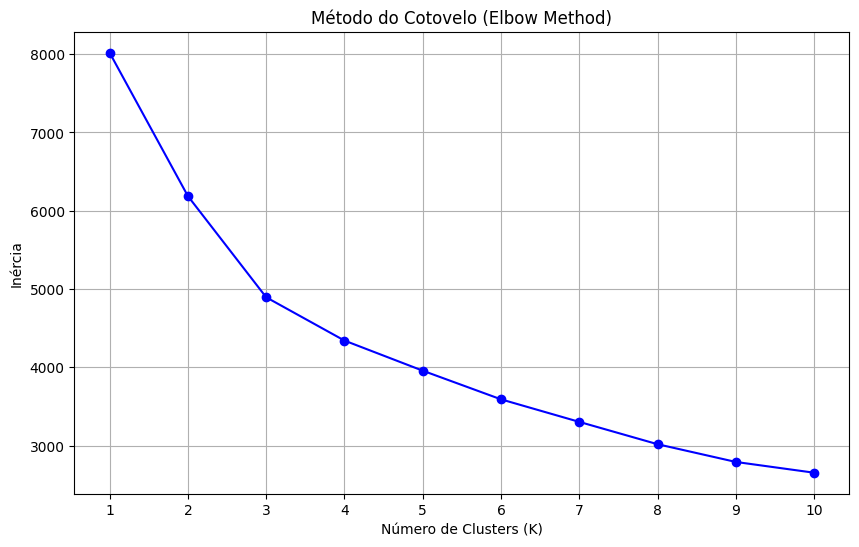

In [4]:
# Bloco 4: Preparação e Descoberta do K Ideal para Clusterização

import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

print("--- Iniciando Etapa 3: Clusterização ---\n")
# Vamos usar apenas as features (características), sem a variável 'Survived'
# Usaremos o X_train que já separamos anteriormente.
features = X_train.copy()

# 1. Padronização dos Dados
# É crucial para algoritmos como o K-Means
print("Padronizando as features para a clusterização...")
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

# Converter de volta para DataFrame para visualização (opcional)
features_scaled = pd.DataFrame(features_scaled, columns=features.columns)

print("Dados padronizados. Amostra:")
print(features_scaled.head())
print("\n" + "="*50 + "\n")


# 2. Encontrando o número ideal de clusters (K) com o Método do Cotovelo
print("Calculando o 'Método do Cotovelo' para encontrar o K ideal...")
inertia = []
K_range = range(1, 11) # Vamos testar de 1 a 10 clusters

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10) # n_init=10 para evitar mínimos locais
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_) # Inertia: soma das distâncias quadradas das amostras para o centro do cluster mais próximo.

print("Cálculo finalizado.")

# 3. Plotando o Gráfico do Cotovelo
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo (Elbow Method)')
plt.grid(True)
plt.xticks(K_range)
plt.show()

--- Executando o K-Means com K=3 ---

--- Análise dos Clusters ---

Análise do perfil médio de cada cluster:
         Survived       Fare        Age    Pclass  FamilySize       Sex
Cluster                                                                
0        0.663415  86.085448  36.592293  1.048780    1.814634  0.487805
2        0.507692  26.741005  20.583333  2.661538    3.928205  0.666667
1        0.217923  11.877671  29.828921  2.694501    1.138493  0.171079


--- Visualizando os Clusters com PCA ---



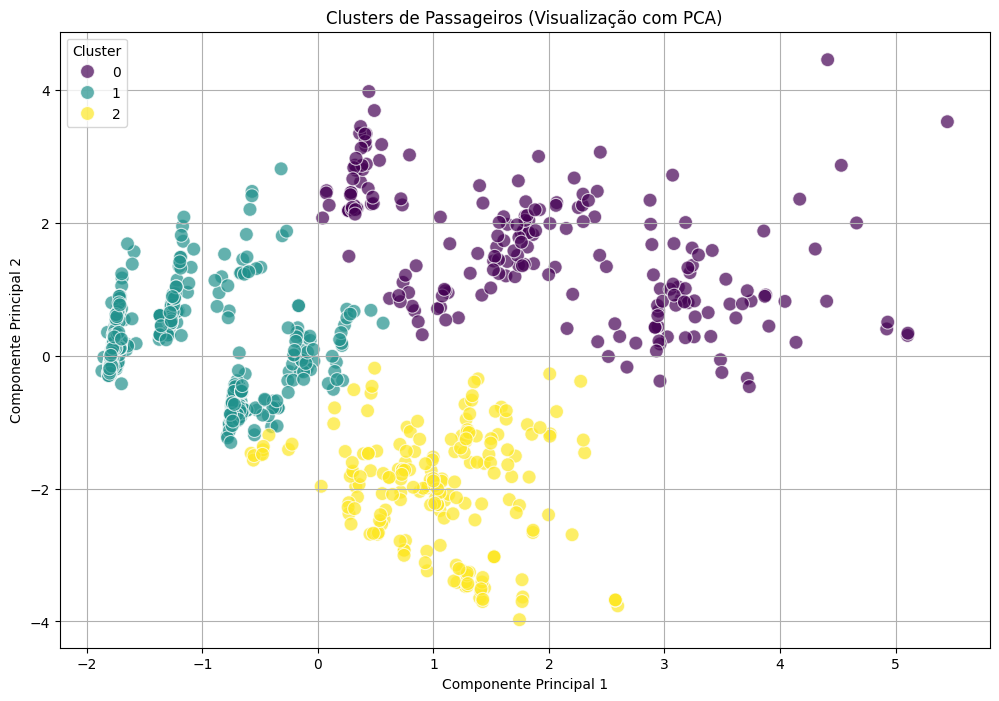

In [5]:
# Bloco 5: Execução do K-Means e Análise dos Clusters

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# ===================================================================
# POR FAVOR, SUBSTITUA O '3' ABAIXO PELO NÚMERO QUE VOCÊ IDENTIFICOU
# COMO O "COTOVELO" NO SEU GRÁFICO.
K_ESCOLHIDO = 3
# ===================================================================

print(f"--- Executando o K-Means com K={K_ESCOLHIDO} ---\n")

# 1. Executando o algoritmo K-Means com o K escolhido
# 'features_scaled' foi o dataframe padronizado que criamos no bloco anterior
kmeans = KMeans(n_clusters=K_ESCOLHIDO, random_state=42, n_init=10)
kmeans.fit(features_scaled)

# Adicionando os rótulos dos clusters ao nosso dataframe original com dados não escalados
# para facilitar a interpretação
train_data_clustered = train_data.copy()
train_data_clustered['Cluster'] = kmeans.labels_

print("--- Análise dos Clusters ---\n")
# Analisando o perfil de cada cluster
# Vamos ver a média de algumas variáveis importantes e a taxa de sobrevivência por cluster
# Adicionamos 'Sex' para ver a proporção de mulheres (onde Sex=1)
cluster_analysis = train_data_clustered.groupby('Cluster')[['Survived', 'Fare', 'Age', 'Pclass', 'FamilySize', 'Sex']].mean()
print("Análise do perfil médio de cada cluster:")
print(cluster_analysis.sort_values(by='Survived', ascending=False))
print("\n" + "="*50 + "\n")


# 2. Visualização dos Clusters com PCA
# O PCA vai reduzir nossas 9 features para apenas 2 componentes principais para que possamos visualizar
print("--- Visualizando os Clusters com PCA ---\n")
pca = PCA(n_components=2, random_state=42)
features_pca = pca.fit_transform(features_scaled)

# Criando um DataFrame com os componentes do PCA e os labels do cluster
df_pca = pd.DataFrame(data=features_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
df_pca['Cluster'] = kmeans.labels_

# Plotando o gráfico de dispersão
plt.figure(figsize=(12, 8))
sns.scatterplot(x='Componente Principal 1', y='Componente Principal 2', hue='Cluster', data=df_pca, palette='viridis', s=100, alpha=0.7)
plt.title('Clusters de Passageiros (Visualização com PCA)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')
plt.legend(title='Cluster')
plt.grid(True)
plt.show()

In [8]:
# Bloco 6: Regras de Associação com Apriori

# A biblioteca mlxtend pode precisar ser instalada.
# No seu terminal ou em uma célula do notebook, rode: pip install mlxtend
from mlxtend.frequent_patterns import apriori, association_rules
import pandas as pd

print("--- Iniciando Etapa 4: Regras de Associação ---\n")

# 1. Preparação dos Dados para Apriori
# O Apriori precisa de dados categóricos. Vamos converter nosso dataset.
# Usaremos o dataframe 'train_data' original, que já foi limpo.
data_apriori = df_train.copy() # Usando o dataframe original carregado no início

# Tratando os mesmos valores nulos que fizemos antes de forma simplificada
data_apriori['Age'].fillna(data_apriori['Age'].median(), inplace=True)
data_apriori['Embarked'].fillna(data_apriori['Embarked'].mode()[0], inplace=True)

# Discretizando variáveis numéricas
data_apriori['Age'] = pd.cut(data_apriori['Age'], bins=[0, 12, 18, 60, 100], labels=['Criança', 'Adolescente', 'Adulto', 'Idoso'])
data_apriori['Fare'] = pd.cut(data_apriori['Fare'], bins=[-1, 10, 50, 600], labels=['Tarifa_Baixa', 'Tarifa_Media', 'Tarifa_Alta'])

# Mapeando outras variáveis para texto para clareza nas regras
data_apriori['Survived'] = data_apriori['Survived'].map({0: 'Não Sobreviveu', 1: 'Sobreviveu'})
data_apriori['Pclass'] = data_apriori['Pclass'].map({1: 'Classe_1', 2: 'Classe_2', 3: 'Classe_3'})
data_apriori['FamilySize'] = data_apriori['SibSp'] + data_apriori['Parch'] + 1
data_apriori['IsAlone'] = data_apriori['FamilySize'].apply(lambda x: 'Sozinho' if x == 1 else 'Com Familia')

# Selecionando as colunas que queremos usar para gerar as regras
data_apriori = data_apriori[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'IsAlone']]

# Convertendo o dataframe para o formato de transações com one-hot encoding
basket = pd.get_dummies(data_apriori)

# 2. Aplicando o Algoritmo Apriori
print("Encontrando itemsets frequentes com Apriori...")
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)

print("Gerando as regras de associação...")
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1)

# 3. Filtrando e Exibindo as Regras Mais Relevantes
# Filtraremos por regras que levam à sobrevivência, com alta confiança e lift.
relevant_rules = rules[
    rules['consequents'].astype(str).str.contains('Sobreviveu') &
    (rules['lift'] > 1.5) &
    (rules['confidence'] > 0.7)
].sort_values(by='lift', ascending=False)


print("\n" + "="*50 + "\n")
print("--- 3 REGRAS DE ASSOCIAÇÃO MAIS RELEVANTES ---")
print("Lendo as regras como: SE (antecedents) ENTÃO (consequents)\n")

# Exibindo as 3 primeiras regras de forma clara
for index, rule in relevant_rules.head(3).iterrows():
    antecedent = ", ".join(list(rule['antecedents']))
    consequent = list(rule['consequents'])[0]
    support = rule['support']
    confidence = rule['confidence']
    lift = rule['lift']

    print(f"Regra #{index}:")
    print(f"  SE: {{{antecedent}}}")
    print(f"  ENTÃO: {{{consequent}}}")
    print(f"  - Suporte: {support:.3f} (A combinação SE+ENTÃO aparece em {support*100:.1f}% dos passageiros)")
    print(f"  - Confiança: {confidence:.3f} (Quando o SE acontece, há {confidence*100:.1f}% de chance do ENTÃO acontecer)")
    print(f"  - Lift: {lift:.3f} (A chance do ENTÃO acontecer é {lift:.1f} vezes maior quando o SE acontece)\n")

if relevant_rules.empty:
    print("Nenhuma regra com os filtros de alta relevância foi encontrada. Tente diminuir os valores de lift e confiança.")

--- Iniciando Etapa 4: Regras de Associação ---

Encontrando itemsets frequentes com Apriori...
Gerando as regras de associação...


--- 3 REGRAS DE ASSOCIAÇÃO MAIS RELEVANTES ---
Lendo as regras como: SE (antecedents) ENTÃO (consequents)

Regra #5708:
  SE: {Age_Adulto, Pclass_Classe_1, Sex_female, IsAlone_Com Familia}
  ENTÃO: {Fare_Tarifa_Alta}
  - Suporte: 0.051 (A combinação SE+ENTÃO aparece em 5.1% dos passageiros)
  - Confiança: 0.918 (Quando o SE acontece, há 91.8% de chance do ENTÃO acontecer)
  - Lift: 7.507 (A chance do ENTÃO acontecer é 7.5 vezes maior quando o SE acontece)

Regra #3996:
  SE: {Pclass_Classe_1, Sex_female, IsAlone_Com Familia}
  ENTÃO: {Fare_Tarifa_Alta}
  - Suporte: 0.061 (A combinação SE+ENTÃO aparece em 6.1% dos passageiros)
  - Confiança: 0.900 (Quando o SE acontece, há 90.0% de chance do ENTÃO acontecer)
  - Lift: 7.357 (A chance do ENTÃO acontecer é 7.4 vezes maior quando o SE acontece)

Regra #5723:
  SE: {Pclass_Classe_1, Sex_female, IsAlone_Com Fam

C:\Users\Luan\AppData\Local\Temp\ipykernel_47416\3924047930.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data_apriori['Age'].fillna(data_apriori['Age'].median(), inplace=True)
C:\Users\Luan\AppData\Local\Temp\ipykernel_47416\3924047930.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behav